## CD4 and CD8 T cell waterfall plot per tumor type

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob as glob
from pathlib import Path
import re
import os
import sys
from collections import defaultdict
from collections import defaultdict
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, LogLocator, FuncFormatter)
from scipy import interpolate
import matplotlib as mpl
import matplotlib.lines as lines
from skbio.diversity.alpha import shannon, simpson, chao1, fisher_alpha, hill


In [ ]:
# publication_output_dir = '/publication_figures'
# project_dir = os.getcwd()
project_dir = '/tcr_seq'
output_dir = os.path.join(project_dir, "outputs", 'boxplot_cancer_types')

In [4]:
def startfig(
        w=4, h=2, rows=1, columns=1, wrs=None, hrs=None, frameon=True, return_first_ax=True
):
    ratio = 0.393701  # 1 cm in inch
    myfigsize = (w * ratio, h * ratio)
    fig = plt.figure(figsize=(myfigsize))
    gs = mpl.gridspec.GridSpec(rows, columns, width_ratios=wrs, height_ratios=hrs)
    if return_first_ax == True:
        a = fig.add_subplot(gs[0, 0], frameon=frameon)
        return a, fig, gs
    else:
        return fig, gs

In [5]:
mylines = 0.75 # updated
mpl.rcParams['axes.linewidth'] = mylines # default 1
mpl.rcParams['ytick.direction'] = 'out' # default 'in'
mpl.rcParams['xtick.direction'] = 'out' # default 'in'
mpl.rcParams['xtick.major.size'] = 3.5 # default 4
mpl.rcParams['ytick.major.size'] = 3.5 # default 4
mpl.rcParams['xtick.major.width'] = mylines # default 0.5
mpl.rcParams['ytick.major.width'] = mylines # default 0.5
mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
mpl.rcParams['grid.color'] = '0.8' # default 'k'
mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
mpl.rcParams['legend.frameon'] = False # default True
mpl.rcParams['font.family'] = 'Arial' # added
mpl.rcParams['figure.dpi']= 300
mpl.rc("savefig", dpi=300)
mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator`

In [6]:
# now add a swarm plot

# https://stackoverflow.com/questions/36153410/how-to-create-a-swarm-plot-with-matplotlib
# maybe also add annotation for outliers

def beeswarm(y, nbins=None, width=1.):
    """
    Returns x coordinates for the points in ``y``, so that plotting ``x`` and
    ``y`` results in a bee swarm plot.
    """
    if nbins is None:
        nbins = np.ceil(len(y) / 6).astype(int)
        # default number of bins

    x = np.zeros(len(y))
    # initialize empty array

    nn, bin_edges = np.histogram(y, bins=nbins)
    # construct a histogram from the data. return list of binned datapoints and list of bin edges

    nmax = nn.max()
    # max number of values in bin

    ibs = []

    for ymin, ymax in zip(bin_edges[:-1], bin_edges[1:]):
        # select exactly the values between bin edges with zipping and looping over zipped values
        i = np.nonzero((y>ymin)*(y<=ymax))[0]
        ibs.append(i)
        # get indices of values to bin (each bin is separate array)

        dx = width / (nmax // 2)

    for i in ibs:
        yy = y[i] # assign values to bin
        if len(i) > 1:
            j = len(i) % 2
            i = i[np.argsort(yy)] # sort index array based on binned values
            a = i[j::2]
            b = i[j+1::2] # split datapoints in two separate arrays if len(i) % 2 != 0 and leave the most middle datapoint out (this is because x position of the middle datapoint will not be changed.
            x[a] = (0.5 + j / 3 + np.arange(len(b))) * dx
            x[b] = (0.5 + j / 3 + np.arange(len(b))) * -dx

    return x

In [ ]:
# load data 
patient_t_cell_df_dict = defaultdict(pd.DataFrame)

for path in glob.glob('/tcr_seq/outputs/boxplot_cancer_types/*.csv'):
    name = os.path.basename(path).split("_")[0]
    patient_t_cell_df_dict[name] = pd.read_csv(path, index_col=0)

patient_t_cell_df_dict["cd8"]


In [ ]:
tumor_name_color_df = pd.read_csv('/tcr_seq/PanCanAtlasTumors_color_coded_by_organ_system_20170302.tsv', sep='\t')

unique_tumor_type_list = list(patient_t_cell_df_dict["cd8"].tumor_type.unique())

tumor_color_dict = dict(tumor_name_color_df.loc[tumor_name_color_df.ton_name.isin(unique_tumor_type_list), :].loc[:, ['ton_name', 'Hex Colors']].values.tolist())

tumor_color_dict.update({'Thyroid': '#F9ED32', 'NSCLC': '#A084BD', 'Prostate': '#7E1918'})
tumor_color_dict.update({'Lung adenocarcinoma': '#D3C3E0', 'Lung squamous': '#A084BD'})

cd8


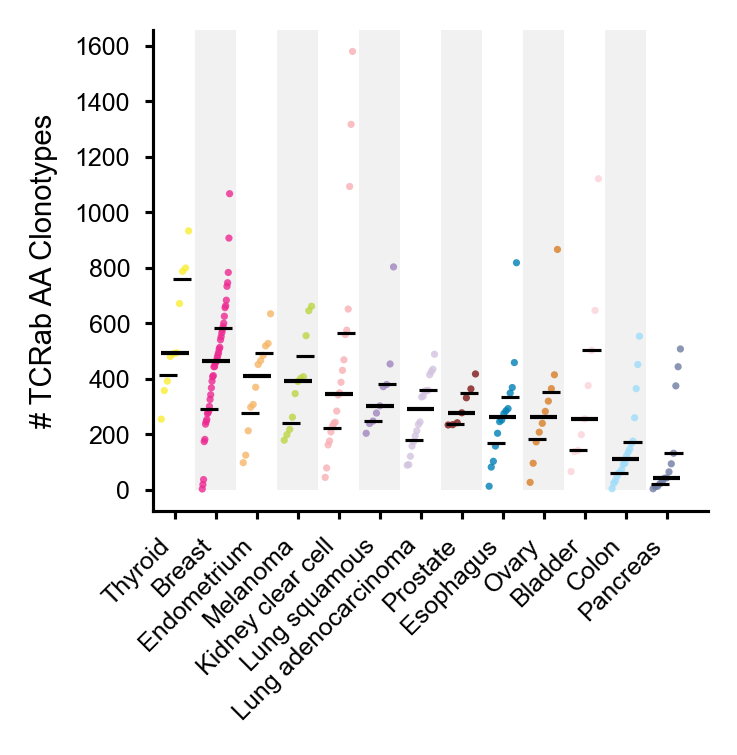

cd8


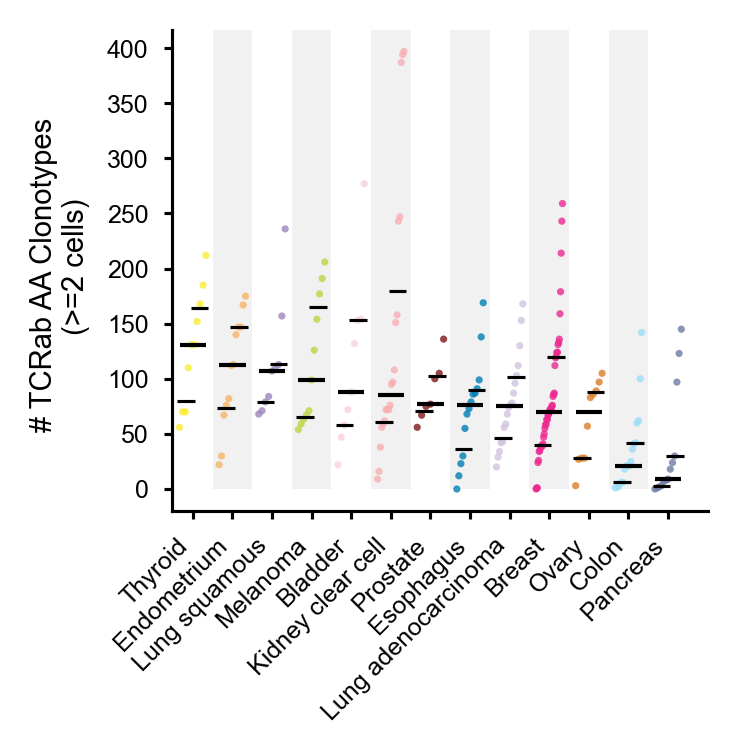

cd8


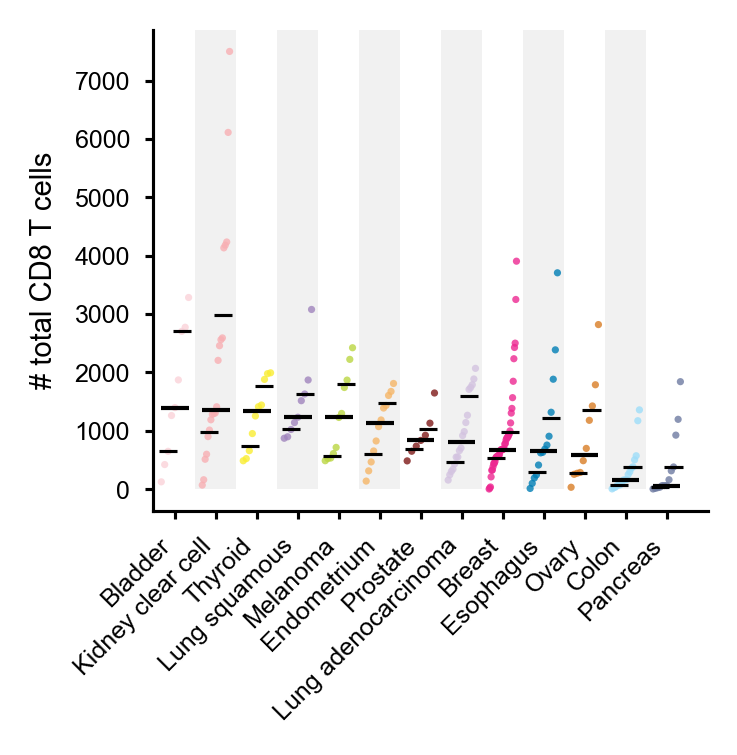

cd4


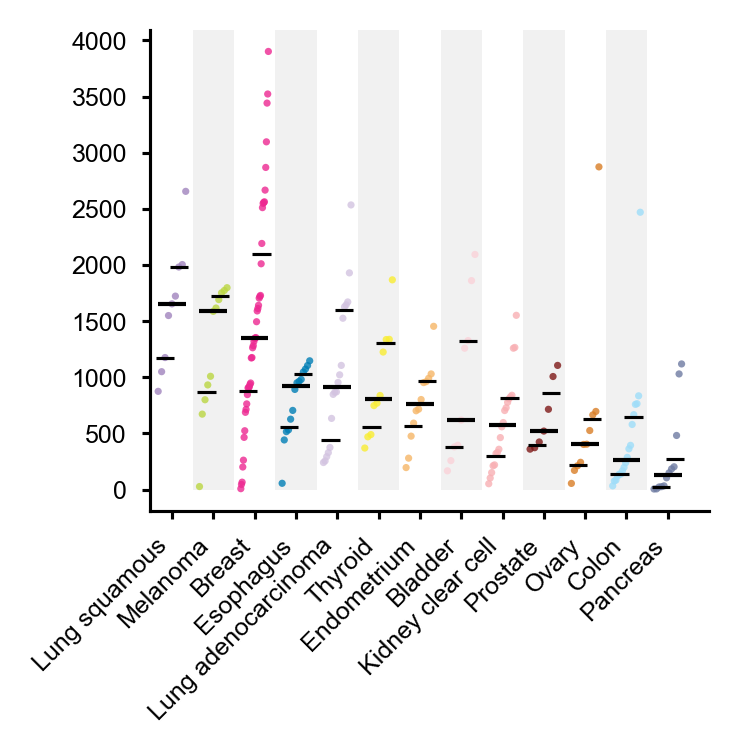

cd4


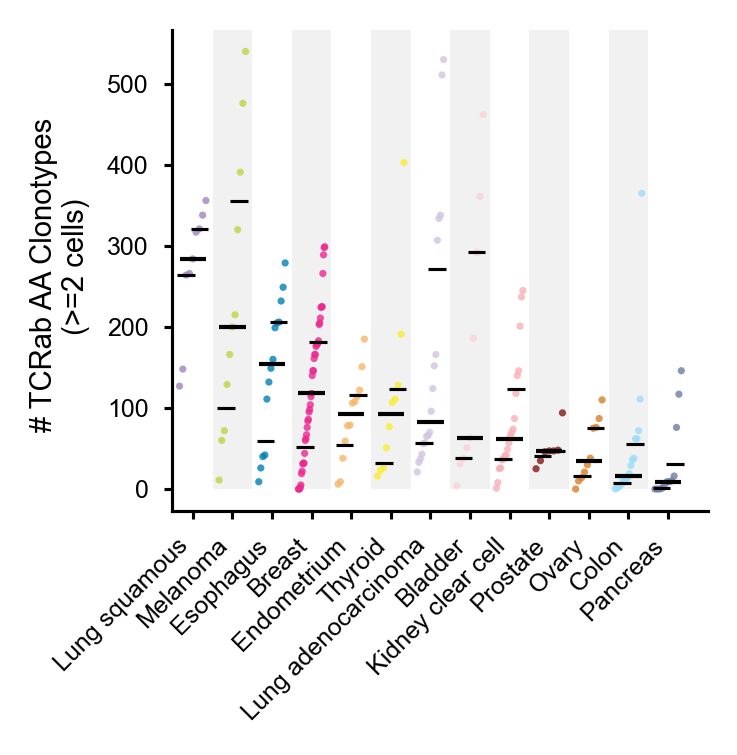

cd4


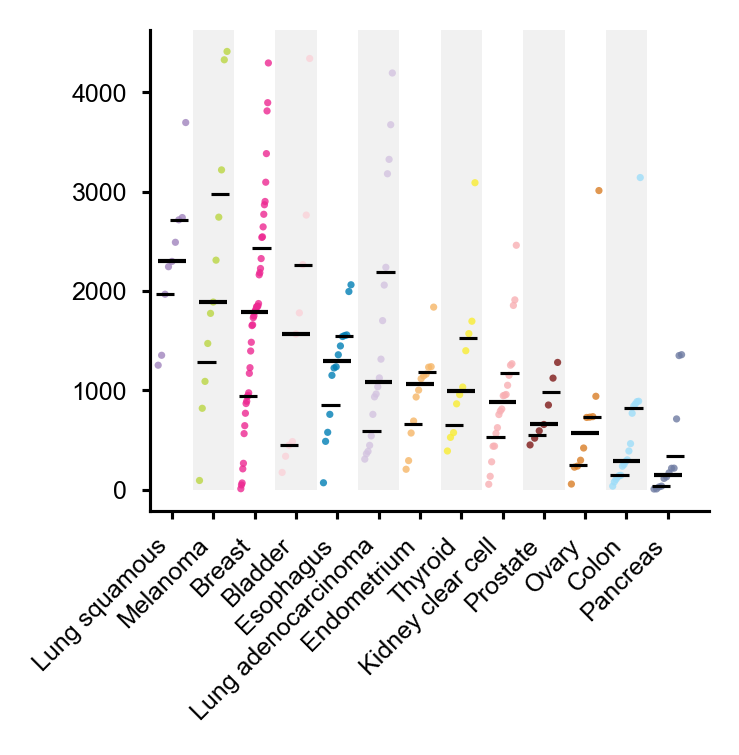

In [40]:
fontsize=7

# Assuming downsampled_filtered_cd8_df, tumor_color_dict, and output_dir are already defined

for key, df in patient_t_cell_df_dict.items():

    tumor_types = df.tumor_type.unique()
    # print(tumor_types)
    positions = [1 + i*0.75 for i in range(len(tumor_types))]
    width = 0.5  
    x_spread_list = []

    if key == "cd8":
        metric_list = ['n_cd8', 'more_or_equal_to_2', 'total_cd8_cells']

    if key == "cd4":
        metric_list = ['n_cd4', 'more_or_equal_to_2', 'total_cd4_cells']

    for metric in metric_list:
        print(key)
        ax, fig, gs = startfig(6.5,6.65) # WxH in cm

        # --- Sort tumor types by median (Ascending, to match the reference image) ---
        median_by_type = df.groupby("tumor_type")[metric].median()
        sorted_tumor_types = median_by_type.sort_values(ascending=False).index.tolist()
        grouped = {k: v for k, v in df.groupby("tumor_type")}

        sorted_groups = [(tt, grouped[tt]) for tt in sorted_tumor_types]
        # ---------------------------------------------------------

        # boxplot_colors = [tumor_color_dict[tt] for tt in sorted_tumor_types]
        color_list = [tumor_color_dict[tt] for tt in sorted_tumor_types]

        for i, (tumor_type, grouped_df) in enumerate(sorted_groups):
            # Extract and drop NaNs for the current group
            values = np.asarray(grouped_df[metric].tolist())
            color = tumor_color_dict[tumor_type]

            if len(values) == 0:
                continue

            values_sorted = np.sort(values)
            
            # --- NEW: Create evenly spaced X coordinates ---
            # This spreads the sorted dots from left to right within the column
            if len(values_sorted) > 1:
                x_spread = np.linspace(positions[i] - width/2, positions[i] + width/2, len(values_sorted))
            else:
                x_spread = [positions[i]]
            
            x_spread_list.append(x_spread)
                
            # Plot the sorted points (using black/dark gray to match the image style)
            ax.scatter(
                x_spread,
                values_sorted,
                color=color, 
                s=3,           
                alpha=0.8,    
                zorder=2,
                edgecolors='none'
            )

            # Plot horizontal line for the group median (using coral/orange like the reference)
            group_median = np.median(values_sorted)
            group_25_quartile = np.percentile(values_sorted, 25)
            group_75_quartile = np.percentile(values_sorted, 75)

            ax.hlines(group_median, positions[i] - width/2, positions[i] + width/2, color='black', linewidth=1, zorder=3)
            ax.hlines(group_25_quartile, np.quantile(x_spread, 0.25) - width/3, np.quantile(x_spread, 0.25) + width/3, color='black', linewidth=0.75, zorder=3)
            ax.hlines(group_75_quartile, np.quantile(x_spread, 0.75) - width/3, np.quantile(x_spread, 0.75) + width/3, color='black', linewidth=0.75, zorder=3)

        # --- Axis Formatting ---
        ax.set_xticks(positions)
        # Rotating 90 degrees to match the vertical text in the reference image
        ax.set_xticklabels(sorted_tumor_types, color='gray', fontsize=fontsize, rotation=90, ha='right')

        ax.tick_params(axis='both', labelsize=fontsize-1, colors='black')
        if metric == 'n_cd8':
            ax.set_ylabel('# TCRab AA Clonotypes', color='black', fontsize=fontsize)
        elif metric == 'more_or_equal_to_2':
            ax.set_ylabel('# TCRab AA Clonotypes \n (>=2 cells)', color='black', fontsize=fontsize)
        elif metric == 'total_cd8_cells':
            ax.set_ylabel('# total CD8 T cells', color='black', fontsize=fontsize)
        
        ymin, ymax = ax.get_ylim()

        for x_1, x_2 in zip(np.array(positions)- 0.75/2, np.array(positions) + 0.75/2): 
            i+=1
            if i % 2 == 0:
                ax.fill_betweenx(
                    [0, ymax], 
                    x_1, 
                    x_2, 
                    edgecolor='none',
                    linewidth=0,
                    color='#E5E5E4', 
                    alpha=0.5, 
                    zorder=0) 
                
        ax.set_ylim(ymin, ymax)  
        ax.set_xlim(0.60, len(tumor_types) * 0.75 + 1)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.tick_params(axis='x', rotation=45) # Hide X tick marks, keeping only labels
        ax.tick_params(axis='both', which='major', length=2)  # default is usually ~3.5–6

        fig.tight_layout()
        # fig.savefig(os.path.join(publication_output_dir, 
        #                          f'{key}_downsampled_filtered_cd8_t_cell_aa_clonotypes_per_tumor_type_{metric}_waterfall_small_dots.pdf'))
        plt.show()